In [49]:
import bluequbit
from bluequbit.library import multi_adder
from math import ceil, log2
from qiskit import QuantumCircuit
from qiskit.circuit import Gate
from math import pi
from qiskit.circuit.library import QFT 
import bluequbit
import warnings
warnings.filterwarnings('ignore')

## **Quantum Circuit Simulation on 14-qbit**

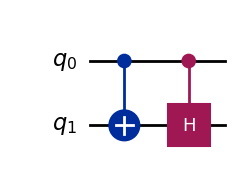

In [50]:
qc = QuantumCircuit(2)

qc.cx(0,1)
qc.ch(0,1)
qc.draw('mpl')

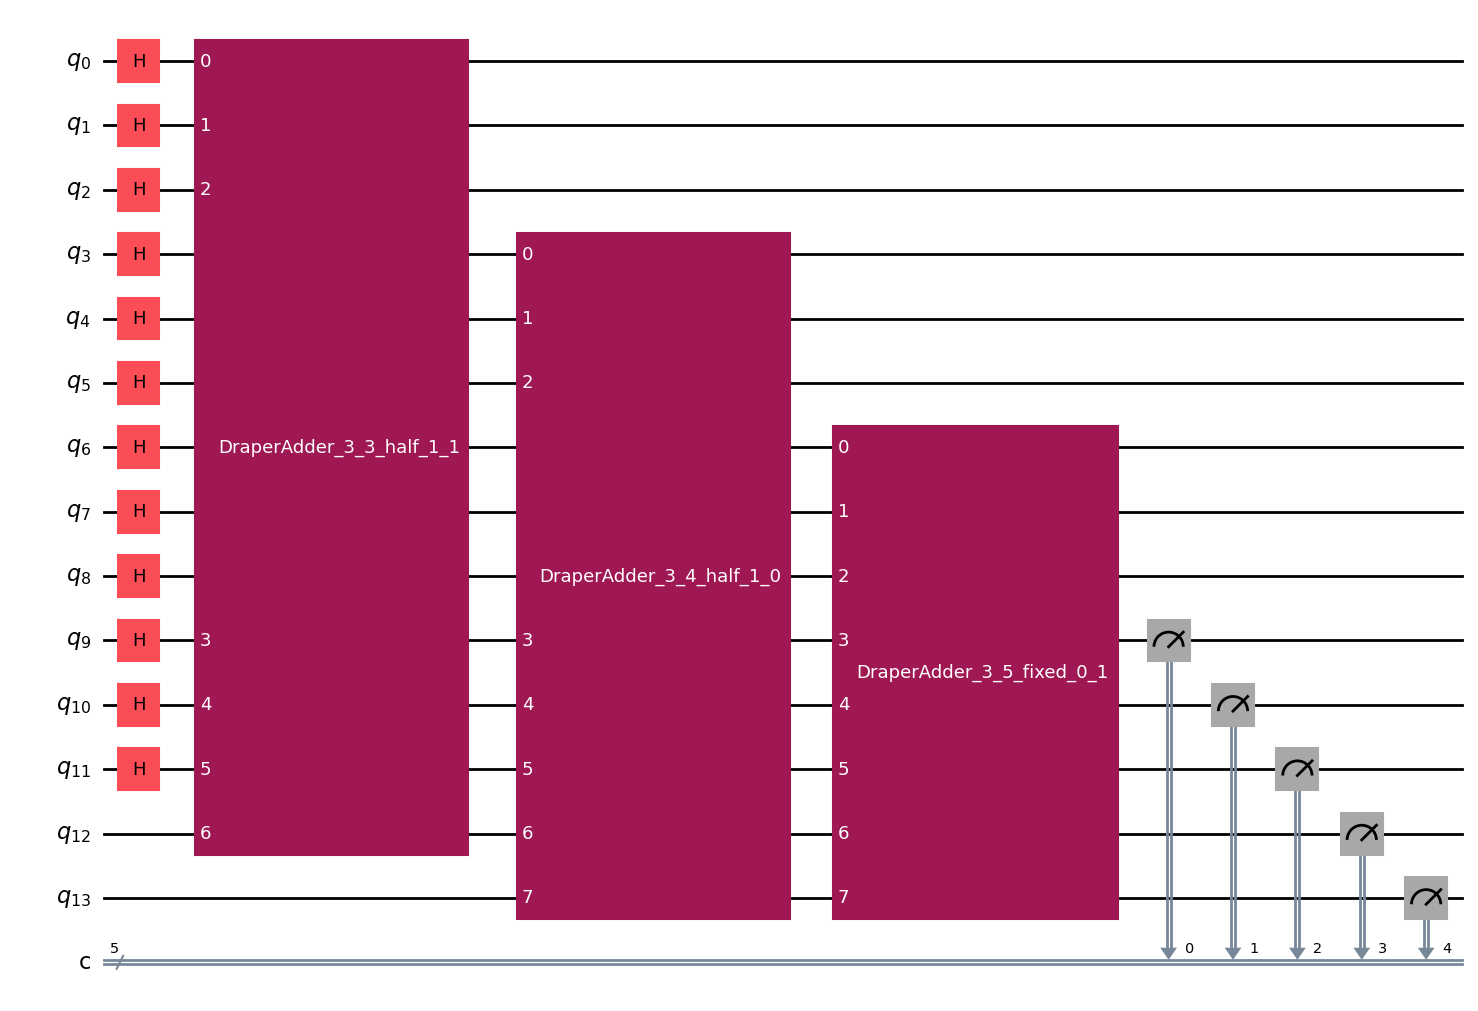

In [51]:
m = 4 # number of registers
n = 3 # number of qubits in each register

num_sum_qubits = int(ceil(log2(m * (2**n - 1) + 0.5)))  
num_qubits = m * n + num_sum_qubits - n

qc_qiskit = QuantumCircuit(num_qubits, num_sum_qubits)
qc_qiskit.h(range(m * n)) 
qc_qiskit.compose(multi_adder(m, n), inplace=True)
qc_qiskit.measure(range(num_qubits-num_sum_qubits, num_qubits), range(num_sum_qubits))
qc_qiskit.draw('mpl')

## **Quantum Fourier Transform**

In [52]:

bq = bluequbit.init("EVWv3LhwF7bQSkRSHeMMwba6YJgB9Oi0")
result = bq.run(qc_qiskit, device='cpu')
print(result.get_counts())


[BQ-PYTHON-SDK][WARNING] - Beta version 0.18.4b1 of BlueQubit Python SDK is being used.


[BQ-PYTHON-SDK][INFO] - Submitted: Job ID: ZjXUtNOOydF03BV5, device: cpu, run status: COMPLETED, created on: 2026-03-28 18:05:17 UTC, cost: $0.00, run time: 8 ms, queue time: 96 ms, num qubits: 14
{'00000': 0.0002441406832076609, '00001': 0.0009765627328306437, '00010': 0.0024414067156612873, '00011': 0.0048828125, '00100': 0.00854492373764515, '00101': 0.013671875, '00110': 0.0205078125, '00111': 0.029296875, '01000': 0.0393066480755806, '01001': 0.0498046875, '01010': 0.0600585974752903, '01011': 0.0693359375, '01100': 0.076904296875, '01101': 0.08203125, '01110': 0.083984375, '01111': 0.08203125, '10000': 0.076904296875, '10001': 0.0693359375, '10010': 0.06005859375, '10011': 0.0498046875, '10100': 0.039306640625, '10101': 0.029296875, '10110': 0.0205078125, '10111': 0.013671875, '11000': 0.008544921875, '11001': 0.004882812034338713, '11010': 0.00244140625, '11011': 0.0009765623253770173, '11100': 0.0002441405667923391, '11101': 1.9751169321217347e-15, '11110': 1.801253890577133e-1

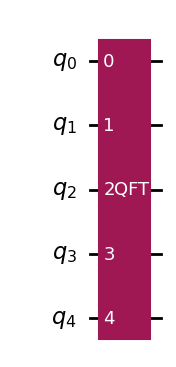

In [53]:
qft_circuit = QFT(num_qubits=5)
qft_circuit.draw('mpl')


In [54]:
qft_circuit = QFT(num_qubits=5)
qft_circuit.measure_all()
result = bq.run(qft_circuit, job_name="QFT on CPU")
print(result.get_counts())

[BQ-PYTHON-SDK][INFO] - Submitted: Job ID: ylDZH7GknxaIypHO, name: QFT on CPU, device: cpu, run status: COMPLETED, created on: 2026-03-28 18:05:19 UTC, cost: $0.00, run time: 5 ms, queue time: 93 ms, num qubits: 5
{'00000': 0.03125, '00001': 0.03125, '00010': 0.03125, '00011': 0.03125, '00100': 0.03125, '00101': 0.03125, '00110': 0.03125, '00111': 0.03125, '01000': 0.03125, '01001': 0.03125, '01010': 0.03125, '01011': 0.03125, '01100': 0.03125, '01101': 0.03125, '01110': 0.03125, '01111': 0.03125, '10000': 0.03125, '10001': 0.03125, '10010': 0.03125, '10011': 0.03125, '10100': 0.03125, '10101': 0.03125, '10110': 0.03125, '10111': 0.03125, '11000': 0.03125, '11001': 0.03125, '11010': 0.03125, '11011': 0.03125, '11100': 0.03125, '11101': 0.03125, '11110': 0.03125, '11111': 0.03125}
